Shape of the dataset: (800, 12)

Column data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows of the dataset:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72 

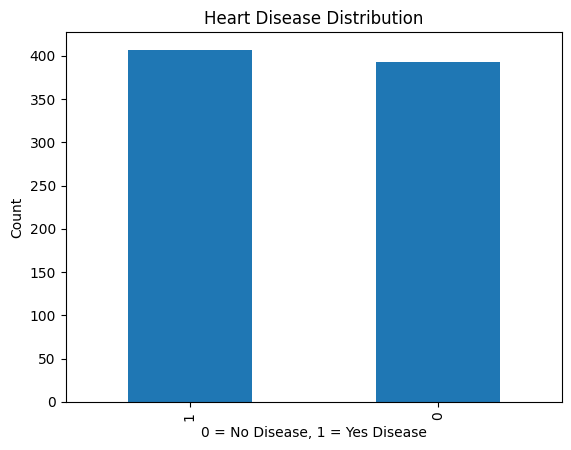

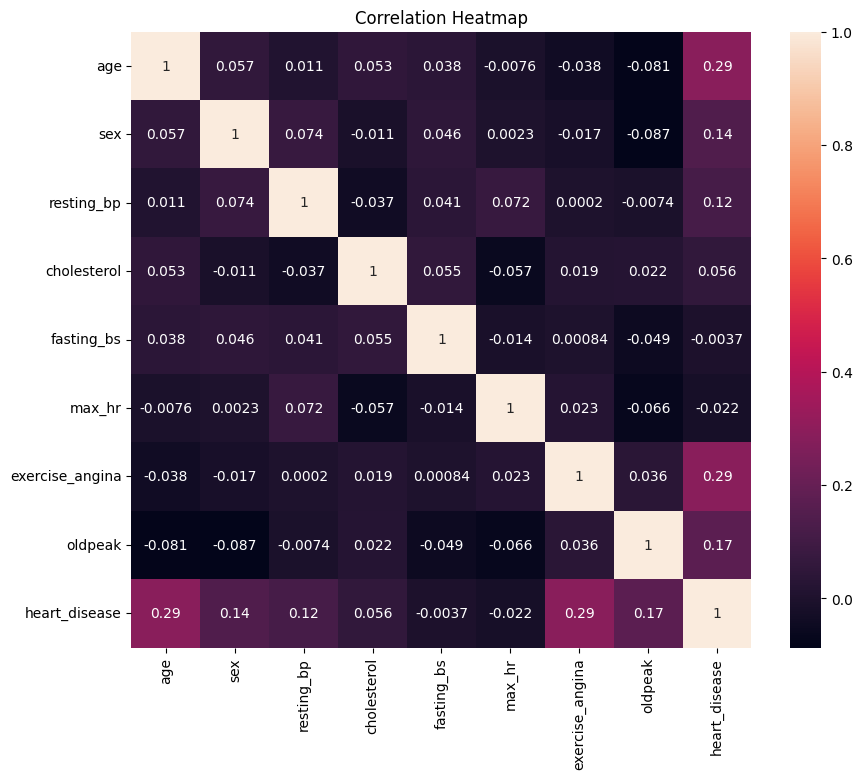

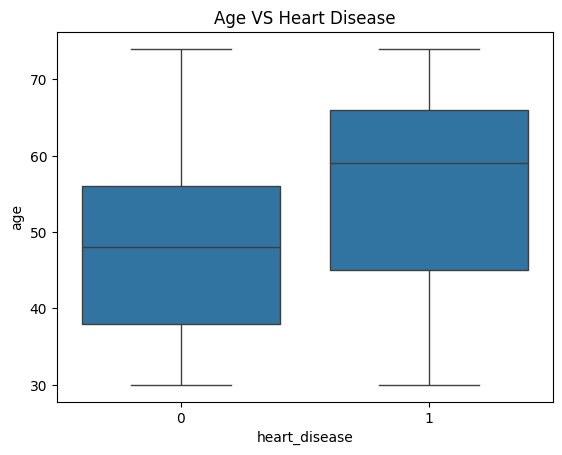


------------------------------
Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


------------------------------
Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


------------------------------
Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               prec

In [2]:
# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------

# Basic Libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools for Ml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# -----------------------------
# STEP 2: LOADING THE DATA
# -----------------------------

# Reading the dataset
df = pd.read_csv('q1_heart_disease.csv')

# Checking Basic Info
print("Shape of the dataset:", df.shape)
print("\nColumn data types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# First few rows to understand the data
print("\nFirst 5 rows of the dataset:\n", df.head())

# ------------------------------
# STEP 3: EXPLORATORY DATA ANALYSIS
# ------------------------------

# 1. Target Distribution
plt.figure()
df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("0 = No Disease, 1 = Yes Disease")
plt.ylabel("Count")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 3. Age VS Heart Disease
plt.figure()
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age VS Heart Disease")
plt.show()

# ----------------------------
# STEP 4: DATA PREPROCESSING
# ----------------------------

# Handling missing values using median
df = df.fillna(df.median(numeric_only=True))

# Splitting features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Convert categorical variables into numbers
X = pd.get_dummies(X, drop_first=True)

# Scaling data (Important for ML Models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )

# ----------------------------
# STEP 5: MODEL TRAINING
# ----------------------------

# Creating Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Training Models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# ----------------------------
# STEP 6: MODEL EVALUATION
# ----------------------------  

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print("\n------------------------------")
    print(name)

    y_pred = model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# ----------------------------
# STEP 7: HYPERPARAMETER TUNING (Example for Random Forest)
# ----------------------------
# Tuning Random Forest 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}   

grid = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("\nBest Parameters found: ", grid.best_params_)

# Evaluating Tuned Model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nTuned Model Results:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))